# **Problem Statement: House Price Prediction using Decision Tree Regression**

## **Objective**

The goal of this project is to build a machine learning model using **Decision Tree Regression** to predict house prices based on various features of the house.

---

## **Dataset Description**

The dataset contains information about houses, including features such as:

* Area (size of the house)
* Number of bedrooms
* Number of bathrooms
* Number of stories
* Parking availability
* Other relevant attributes

The target variable is:

* **Price of the house**

---

## **Problem Definition**

Given the input features of a house, develop a **Decision Tree Regression** model that can accurately predict the **price** of the house.

---

## **Tasks**

1. Load and explore the dataset

2. Perform data preprocessing:

   * Handle missing values
   * Encode categorical variables (use One-Hot Encoding if applicable)

3. Split the dataset into training and testing sets

4. Train a Decision Tree Regressor:

   * Initialize the model
   * Tune important hyperparameters such as:

     * `max_depth`
     * `min_samples_split`
     * `min_samples_leaf`

5. Evaluate the model using suitable regression metrics:

   * Mean Squared Error (MSE)
   * R² Score

6. Analyze model performance:

   * Compare training and testing scores
   * Check for overfitting
   * Visualize predictions (if applicable)

---


In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [145]:
df = pd.read_csv('./Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [146]:
df = df[['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']]
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
0,13300000,7420,4,2,3,2,yes,no,no,no,yes,yes,furnished
1,12250000,8960,4,4,4,3,yes,no,no,no,yes,no,furnished
2,12250000,9960,3,2,2,2,yes,no,yes,no,no,yes,semi-furnished
3,12215000,7500,4,2,2,3,yes,no,yes,no,yes,yes,furnished
4,11410000,7420,4,1,2,2,yes,yes,yes,no,yes,no,furnished


In [147]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0:1]

In [148]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), slice(5,12))], remainder='passthrough')
X = np.array(ct.fit_transform(X))

In [149]:
feature_names = ct.get_feature_names_out()

In [150]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [151]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(random_state=0, max_depth=2)
regressor.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_

In [152]:
y_train_pred = regressor.predict(X_train)
y_test_pred = regressor.predict(X_test)

In [153]:
from sklearn.metrics import r2_score, mean_squared_error

print(f"R^2 Score (Training Dataset) = {r2_score(y_train, y_train_pred)}")
print(f"R^2 Score (Test Dataset) = {r2_score(y_test, y_test_pred)}")

print(f"\nMSE Score (Training Dataset) = {mean_squared_error(y_train, y_train_pred)}")
print(f"MSE Score (Test Dataset) = {mean_squared_error(y_test, y_test_pred)}")

R^2 Score (Training Dataset) = 0.45956354067549143
R^2 Score (Test Dataset) = 0.41400600828199074

MSE Score (Training Dataset) = 1969448828445.374
MSE Score (Test Dataset) = 1688552334682.2786


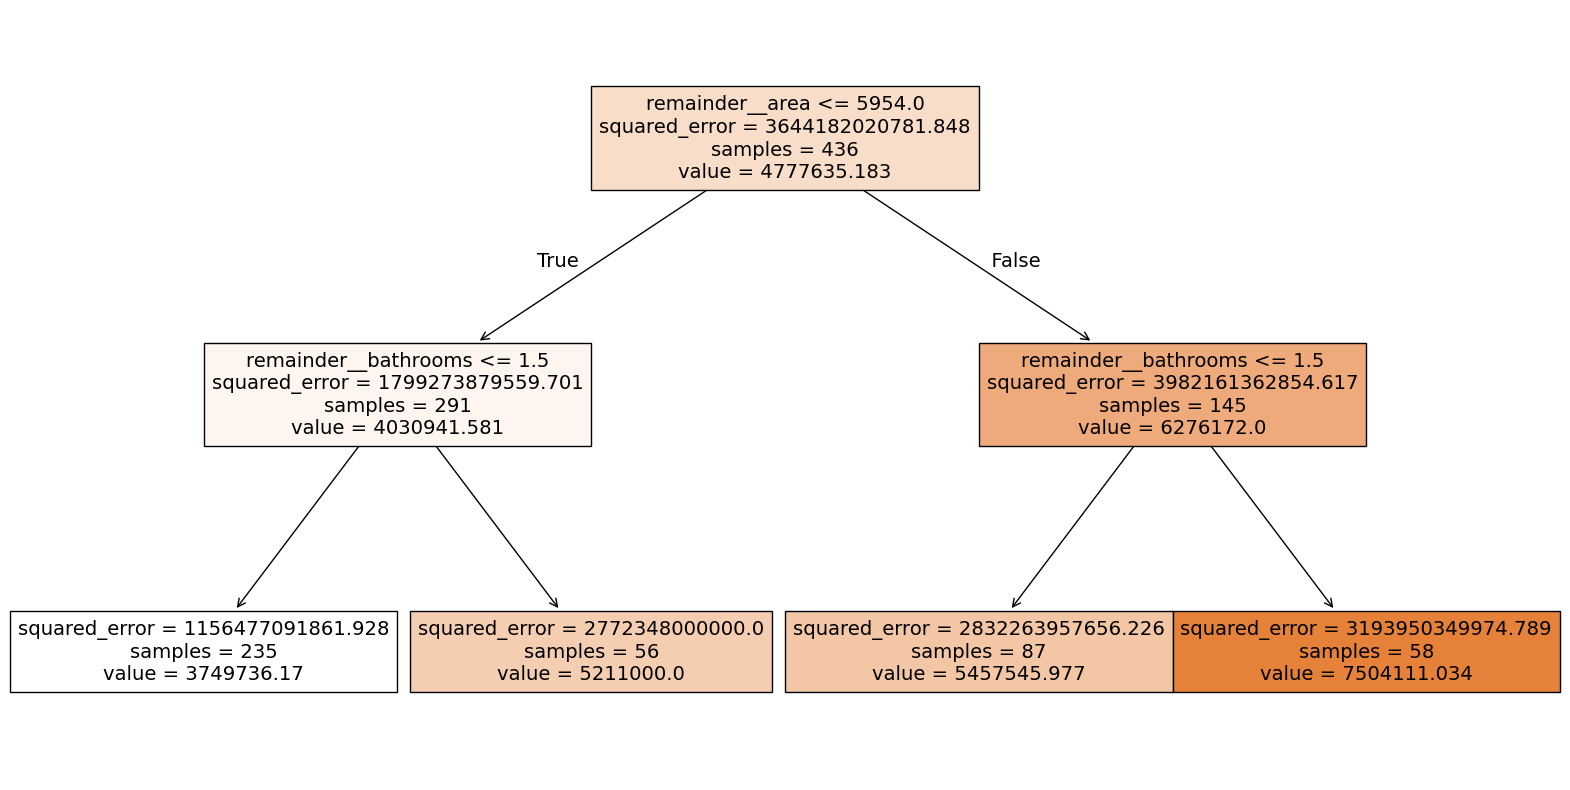

In [154]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(regressor, feature_names=feature_names, filled=True)
plt.show()

In [ ]:
data = [[6850, 4, 3, 4, 5, "yes", "yes", "yes", "no", "no", "no", "unfurnished"]]

data = np.array(ct.transform(data))
print(regressor.predict(data))

[7504111.03448276]


c:\Users\yeshw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
